In [1]:
!pip install ultralytics opencv-python matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 75.0 MB/s eta 0:00:00


In [25]:
!pip install ultralytics pycocotools

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [30]:
model = YOLO("yolov8n.pt")  # nano model (fast)

(np.float64(-0.5), np.float64(399.5), np.float64(287.5), np.float64(-0.5))

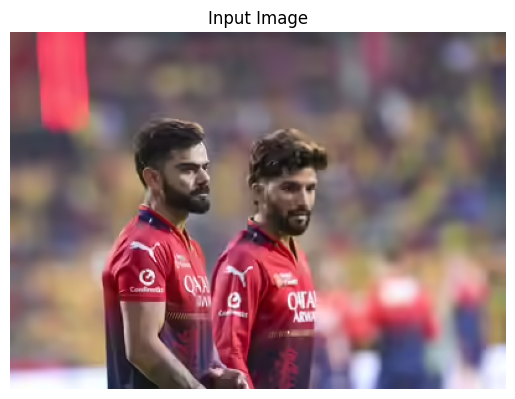

In [31]:
image_path = "/content/drive/MyDrive/input_vk.avif"  # replace with your image
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.title("Input Image")
plt.axis("off")

In [32]:
results = model(image)


0: 480x640 4 persons, 9.8ms
Speed: 2.1ms preprocess, 9.8ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)


(np.float64(-0.5), np.float64(399.5), np.float64(287.5), np.float64(-0.5))

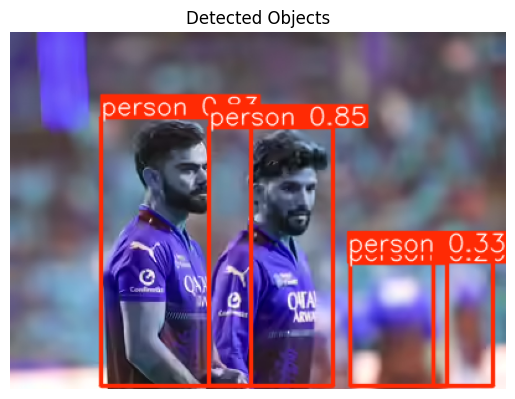

In [33]:
annotated = results[0].plot()

plt.imshow(annotated)
plt.title("Detected Objects")
plt.axis("off")

In [34]:
detections = results[0].boxes

pred_boxes = detections.xyxy.cpu().numpy()
scores = detections.conf.cpu().numpy()
classes = detections.cls.cpu().numpy()

print("Predicted Boxes:\n", pred_boxes)

Predicted Boxes:
 [[     160.57      77.299      260.32      285.32]
 [     73.325      69.002      194.61      285.58]
 [     341.87      179.96      389.53       285.9]
 [     274.58      186.19      352.05      285.68]]


In [35]:
def compute_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    intersection = max(0, x2 - x1) * max(0, y2 - y1)

    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])

    union = area1 + area2 - intersection

    return intersection / union if union > 0 else 0

In [41]:
# Example: [x1, y1, x2, y2]
ground_truth_boxes = [
    [160, 77, 260, 285],
    [73, 69, 194, 285 ],
    [341, 179, 389, 285],
    [274, 186, 352, 185]
    # replace with actual GT
]

In [42]:
ious = []

for pred in pred_boxes:
    for gt in ground_truth_boxes:
        iou = compute_iou(pred, gt)
        ious.append(iou)

print("IoU values:", ious)
print("Average IoU:", np.mean(ious) if ious else 0)

IoU values: [np.float32(0.9882881), np.float32(0.17386036), np.float32(0.0), np.float32(0.0), np.float32(0.18057986), np.float32(0.989652), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.95452935), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.093257315), np.float32(0.0)]
Average IoU: 0.21126044


In [43]:
iou_threshold = 0.5

TP = 0
FP = 0
FN = 0

matched = set()

for i, pred in enumerate(pred_boxes):
    best_iou = 0
    best_gt = -1

    for j, gt in enumerate(ground_truth_boxes):
        iou = compute_iou(pred, gt)
        if iou > best_iou:
            best_iou = iou
            best_gt = j

    if best_iou >= iou_threshold:
        TP += 1
        matched.add(best_gt)
    else:
        FP += 1

FN = len(ground_truth_boxes) - len(matched)

precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0

print("Precision:", precision)
print("Recall:", recall)

Precision: 0.75
Recall: 0.75



0: 480x640 (no detections), 14.1ms
Speed: 3.7ms preprocess, 14.1ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)


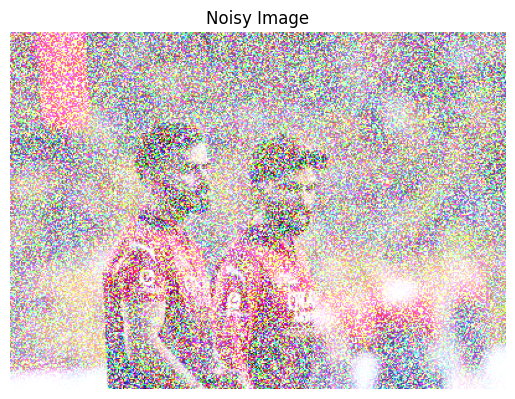

In [44]:
noise = np.random.normal(0, 25, image.shape).astype(np.uint8)
noisy_image = cv2.add(image, noise)

plt.imshow(cv2.cvtColor(noisy_image, cv2.COLOR_BGR2RGB))
plt.title("Noisy Image")
plt.axis("off")

results_noise = model(noisy_image)


0: 480x640 4 persons, 9.7ms
Speed: 3.1ms preprocess, 9.7ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)


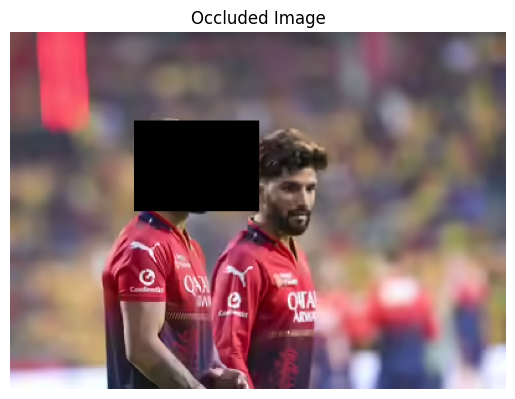

In [45]:
occluded = image.copy()
h, w, _ = occluded.shape

cv2.rectangle(occluded, (w//4, h//4), (w//2, h//2), (0,0,0), -1)

plt.imshow(cv2.cvtColor(occluded, cv2.COLOR_BGR2RGB))
plt.title("Occluded Image")
plt.axis("off")

results_occ = model(occluded)